In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


# 数据预处理


### 查看数据集基本信息

In [2]:
data=pd.read_csv('../data/ecommerce_data.csv')
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564169 entries, 0 to 564168
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     564169 non-null  int64  
 1   event_time     564169 non-null  object 
 2   order_id       564169 non-null  int64  
 3   product_id     564169 non-null  int64  
 4   category_id    564169 non-null  float64
 5   category_code  434799 non-null  object 
 6   brand          536945 non-null  object 
 7   price          564169 non-null  float64
 8   user_id        564169 non-null  float64
 9   age            564169 non-null  float64
 10  sex            564169 non-null  object 
 11  local          564169 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 51.7+ MB


,Unnamed: 0,event_time,order_id,product_id,category_id,category_code,brand,price,user_id,age,sex,local
0,0,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南
1,1,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南
2,2,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18,38.0,女,北京
3,3,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18,38.0,女,北京
4,4,2020-04-24 19:16:21 UTC,2294584263154074236,2273948316817424439,2.268105e+18,NaN,karcher,217.57,1.515916e+18,32.0,女,广东


In [3]:
data.describe()

,Unnamed: 0,order_id,product_id,category_id,price,user_id,age
count,5.641690e+05,5.641690e+05,5.641690e+05,5.641690e+05,564169.000000,5.641690e+05,564169.000000
mean,1.792965e+06,2.370552e+18,1.695711e+18,2.272919e+18,208.269324,1.515916e+18,33.184388
std,7.745342e+05,2.025138e+16,3.290688e+17,2.158282e+16,304.559875,2.379056e+07,10.122088
min,0.000000e+00,2.294360e+18,1.515966e+18,2.268105e+18,0.000000,1.515916e+18,16.000000
25%,1.658965e+06,2.353294e+18,1.515966e+18,2.268105e+18,23.130000,1.515916e+18,24.000000
50%,1.861597e+06,2.376886e+18,1.515966e+18,2.268105e+18,87.940000,1.515916e+18,33.000000
75%,2.473370e+06,2.388441e+18,1.515966e+18,2.268105e+18,277.750000,1.515916e+18,42.000000
max,2.633520e+06,2.388441e+18,2.388434e+18,2.374499e+18,18328.680000,1.515916e+18,50.000000


### 处理缺失值

In [4]:

data.isnull().sum()

Unnamed: 0            0
event_time            0
order_id              0
product_id            0
category_id           0
category_code    129370
brand             27224
price                 0
user_id               0
age                   0
sex                   0
local                 0
dtype: int64

In [5]:
data['category_code']=data['category_code'].fillna('missing')
data['brand']=data['brand'].fillna('missing')

### 时间特征工程

In [6]:
data['event_time']=pd.to_datetime(data['event_time'],utc=True)
data['year']=data["event_time"].dt.year
data['month']=data["event_time"].dt.month
data['day']=data["event_time"].dt.day
data['hour']=data["event_time"].dt.hour
data.head()

,Unnamed: 0,event_time,order_id,product_id,category_id,category_code,brand,price,user_id,age,sex,local,year,month,day,hour
0,0,2020-04-24 11:50:39+00:00,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南,2020,4,24,11
1,1,2020-04-24 11:50:39+00:00,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18,24.0,女,海南,2020,4,24,11
2,2,2020-04-24 14:37:43+00:00,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18,38.0,女,北京,2020,4,24,14
3,3,2020-04-24 14:37:43+00:00,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18,38.0,女,北京,2020,4,24,14
4,4,2020-04-24 19:16:21+00:00,2294584263154074236,2273948316817424439,2.268105e+18,missing,karcher,217.57,1.515916e+18,32.0,女,广东,2020,4,24,19


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564169 entries, 0 to 564168
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   Unnamed: 0     564169 non-null  int64              
 1   event_time     564169 non-null  datetime64[ns, UTC]
 2   order_id       564169 non-null  int64              
 3   product_id     564169 non-null  int64              
 4   category_id    564169 non-null  float64            
 5   category_code  564169 non-null  object             
 6   brand          564169 non-null  object             
 7   price          564169 non-null  float64            
 8   user_id        564169 non-null  float64            
 9   age            564169 non-null  float64            
 10  sex            564169 non-null  object             
 11  local          564169 non-null  object             
 12  year           564169 non-null  int32              
 13  month          564169 non-nul

### 处理缺失值

In [8]:
data['category_code']=data['category_code'].fillna('missing')
data['brand']=data['brand'].fillna('missing')
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564169 entries, 0 to 564168
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   Unnamed: 0     564169 non-null  int64              
 1   event_time     564169 non-null  datetime64[ns, UTC]
 2   order_id       564169 non-null  int64              
 3   product_id     564169 non-null  int64              
 4   category_id    564169 non-null  float64            
 5   category_code  564169 non-null  object             
 6   brand          564169 non-null  object             
 7   price          564169 non-null  float64            
 8   user_id        564169 non-null  float64            
 9   age            564169 non-null  float64            
 10  sex            564169 non-null  object             
 11  local          564169 non-null  object             
 12  year           564169 non-null  int32              
 13  month          564169 non-nul

Unnamed: 0       0
event_time       0
order_id         0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
age              0
sex              0
local            0
year             0
month            0
day              0
hour             0
dtype: int64

### 删除重复值,如果没有则不执行

In [9]:
data.duplicated().sum()

np.int64(0)

# 多维度销售数据分析

### 每月成交金额可视化

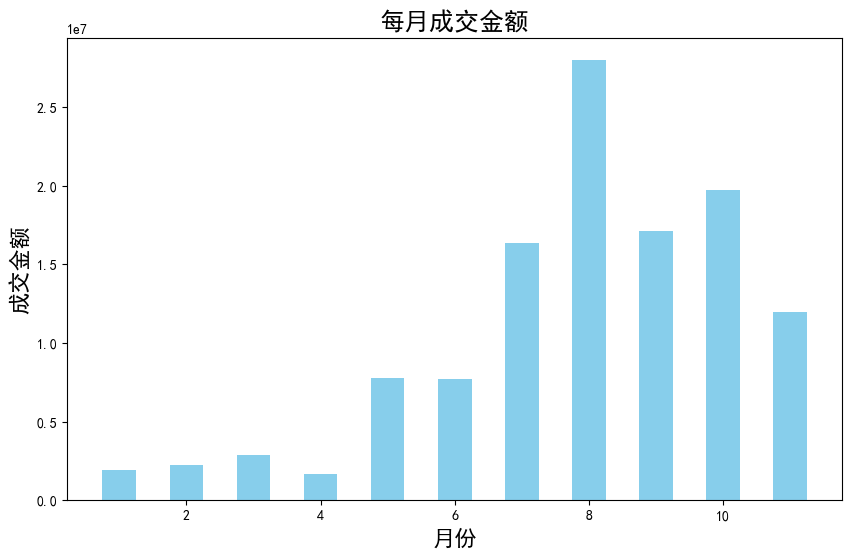

In [10]:
data_month_amount=data.groupby('month')['price'].sum()
plt.figure(figsize=(10,6))
plt.bar(x=data_month_amount.index,height=data_month_amount.values,color='skyblue',width=0.5)
plt.title('每月成交金额',fontsize=18)
plt.xlabel('月份',fontsize=16)
plt.ylabel('成交金额',fontsize=16)
plt.savefig('../images/每月成交金额.png')
plt.show()
plt.close()



### 每月消费人数

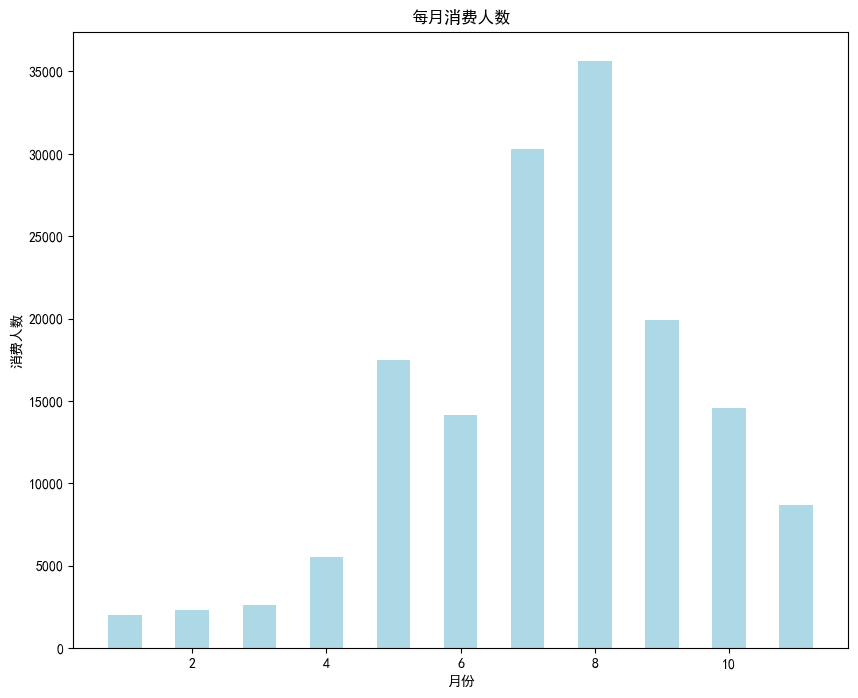

In [11]:
month_distinct_users=data.groupby('month')['user_id'].nunique()
plt.figure(figsize=(10,8))
plt.bar(x=month_distinct_users.index,height=month_distinct_users.values,color='lightblue',width=0.5)
plt.xlabel('月份')
plt.ylabel('消费人数')
plt.title('每月消费人数')
plt.savefig('../images/每月消费人数.png')
plt.show()
plt.close()


### 每月订单数量

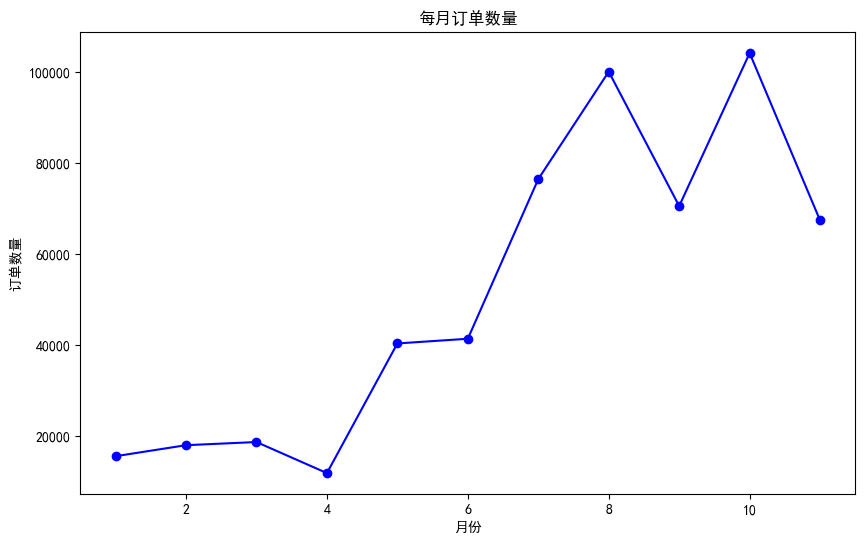

In [12]:
#每月订单数量
month_order_count = data.groupby('month')['order_id'].count()
plt.figure(figsize=(10,6))
plt.plot(month_order_count.index, month_order_count.values, marker='o', color='blue')
plt.xlabel('月份')
plt.ylabel('订单数量')
plt.title('每月订单数量')
plt.savefig('../images/每月订单数量.png')
plt.show()
plt.close()


### 不同省份订单数量

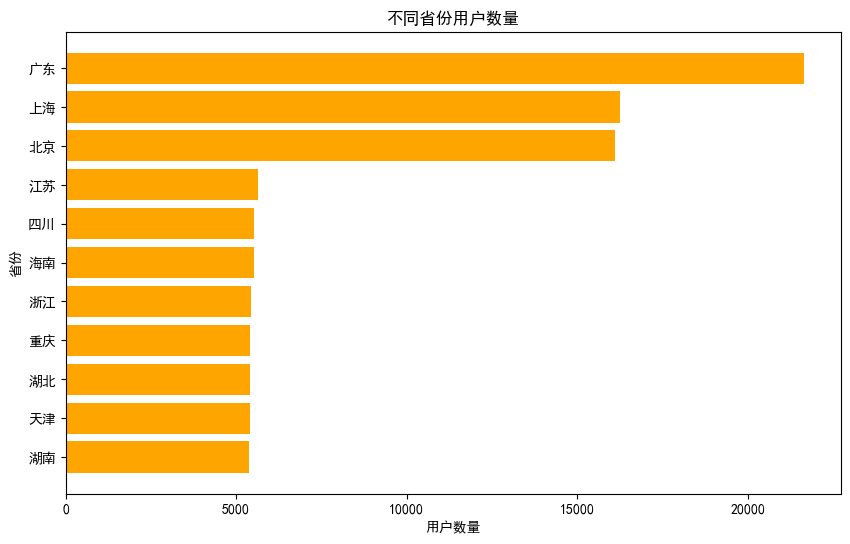

In [13]:
province_user=data.groupby('local')['user_id'].nunique().sort_values(ascending=True)
plt.figure(figsize=(10,6))
plt.barh(y=province_user.index,width=province_user.values,color='orange')

plt.title('不同省份用户数量')
plt.xlabel('用户数量')
plt.ylabel('省份')
plt.savefig('../images/不同省份用户数量.png')
plt.show()
plt.close()


In [14]:
### 不同省份订单数量

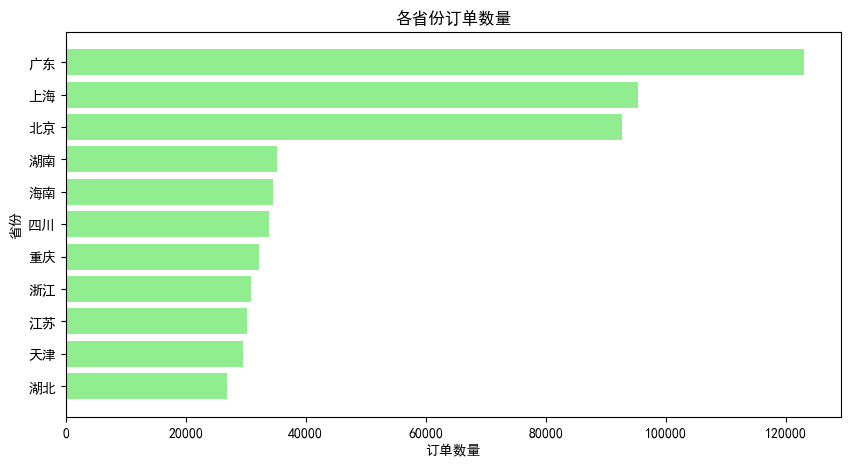

In [15]:
province_order=data.groupby('local')['order_id'].count().sort_values(ascending=True)
plt.figure(figsize=(10,5))
plt.barh(y=province_order.index,width=province_order.values,color='lightgreen')
plt.title('各省份订单数量')
plt.xlabel('订单数量')
plt.ylabel('省份')
plt.savefig('../images/各省份订单数量.png')
plt.show()
plt.close()


### 不同省份成交金额

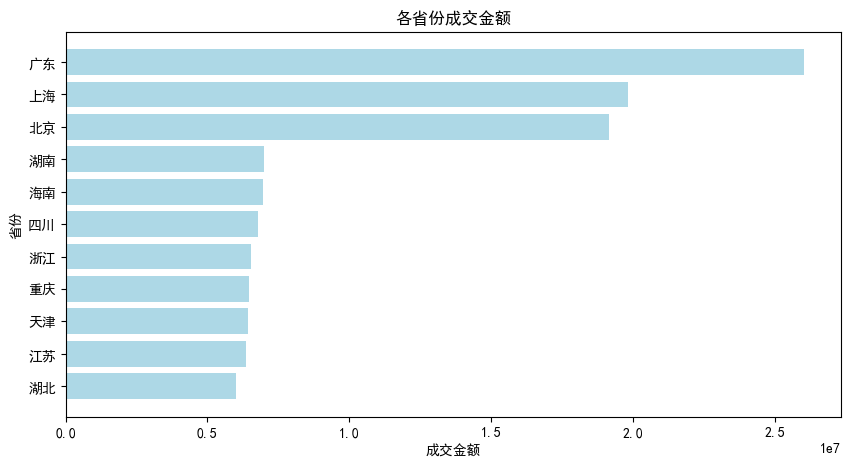

In [16]:
province_amount=data.groupby('local')['price'].sum().sort_values(ascending=True)
plt.figure(figsize=(10,5))
plt.barh(y=province_amount.index,width=province_amount.values,color='lightblue')
plt.title('各省份成交金额')
plt.xlabel('成交金额')
plt.ylabel('省份')
plt.savefig('../images/不同省份成交金额.png')
plt.show()
plt.close()

### 订单随小时数变化

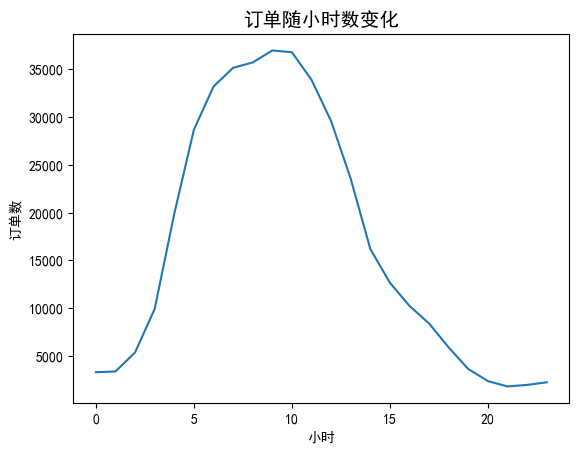

In [17]:
province_user = data.groupby('hour')['order_id'].nunique()
plt.plot(province_user.index, province_user.values)
plt.title('订单随小时数变化', fontsize=14)
plt.xlabel('小时')
plt.ylabel('订单数')
plt.savefig('../images/订单随小时数变化.png')
plt.show()

### 未完成支付的订单

In [18]:
data[data['price'] == 0].count()

Unnamed: 0       39
event_time       39
order_id         39
product_id       39
category_id      39
category_code    39
brand            39
price            39
user_id          39
age              39
sex              39
local            39
year             39
month            39
day              39
hour             39
dtype: int64

# 用户消费行为分析

In [19]:
data.groupby('user_id').agg({'order_id': 'nunique', 'price': 'sum'}).describe()

,order_id,price
count,93823.000000,93823.000000
mean,4.269081,1252.348533
std,18.192114,4205.819875
min,1.000000,0.000000
25%,1.000000,145.595000
50%,2.000000,460.580000
75%,3.000000,1152.480000
max,666.000000,165439.030000


### 消费次数与消费金额的关系

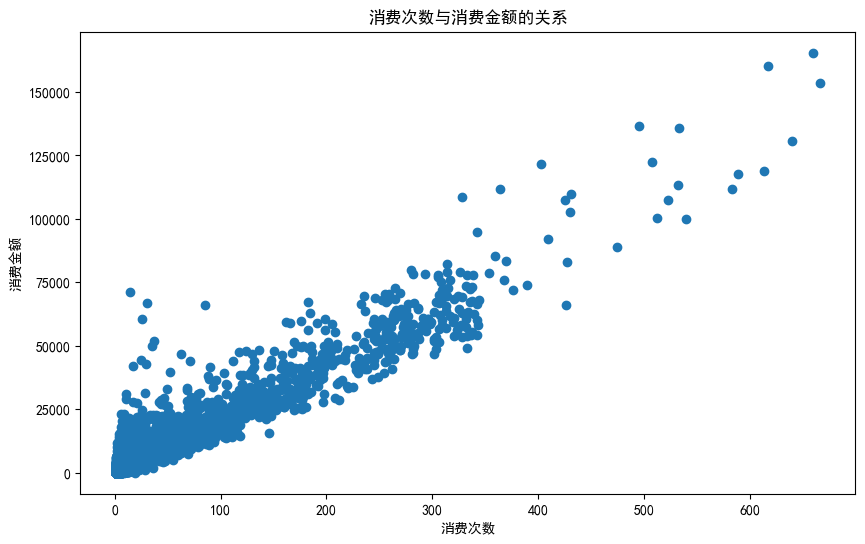

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(x=data.groupby('user_id')['order_id'].nunique(),
           y=data.groupby('user_id')['price'].sum())
plt.xlabel('消费次数')
plt.ylabel('消费金额')
plt.title('消费次数与消费金额的关系')
plt.savefig('../images/消费次数与消费金额的关系.png')
plt.show()

In [21]:
purchase_time = data.groupby('user_id').apply(lambda x: x['event_time'] - x['event_time'].shift()).dt.days
purchase_time.describe()

C:\Users\coolc\AppData\Local\Temp\ipykernel_23520\2190318171.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  purchase_time = data.groupby('user_id').apply(lambda x: x['event_time'] - x['event_time'].shift()).dt.days


count    470346.000000
mean          9.664460
std         377.604099
min      -18452.000000
25%           0.000000
50%           0.000000
75%           1.000000
max       18557.000000
Name: event_time, dtype: float64

## RFM模型构建

In [22]:
snapshot_date = data['event_time'].max()

rfm = data.groupby('user_id').agg({
    'event_time': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'price': 'sum'
})

rfm.columns = ['R', 'F', 'M']

rfm.head()

,R,F,M
user_id,,,
1.515916e+18,135,1,416.64
1.515916e+18,24,2,56.43
1.515916e+18,4,14,7530.34
1.515916e+18,12,24,5074.47
1.515916e+18,129,2,182.83


### 分位数打分

In [23]:
rfm['R_score'] = pd.qcut(rfm['R'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['F'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['M'], 4, labels=[1,2,3,4])

### 综合评分

In [24]:
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm.head()

,R,F,M,R_score,F_score,M_score,RFM_score
user_id,,,,,,,
1.515916e+18,135,1,416.64,1,1,2,112
1.515916e+18,24,2,56.43,4,2,1,421
1.515916e+18,4,14,7530.34,4,4,4,444
1.515916e+18,12,24,5074.47,4,4,4,444
1.515916e+18,129,2,182.83,1,2,2,122


### 用户分层

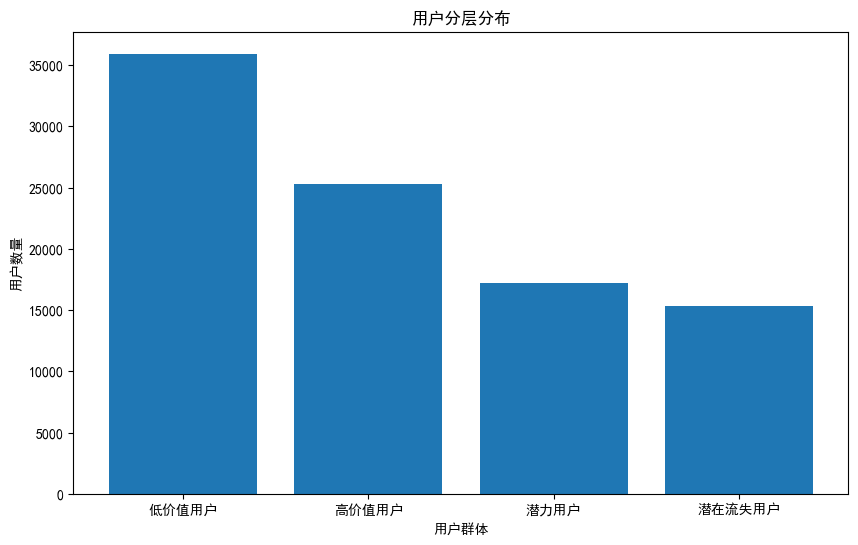

In [25]:
# 用户分层
def segment(row):
    if row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return '高价值用户'
    elif row['R_score'] >= 3 and row['F_score'] >= 2:
        return '潜力用户'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return '潜在流失用户'
    else:
        return '低价值用户'

rfm['segment'] = rfm.apply(segment, axis=1)

segment_counts = rfm['segment'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(segment_counts.index, segment_counts.values)
plt.title('用户分层分布')
plt.xlabel('用户群体')
plt.ylabel('用户数量')
plt.savefig('../images/用户分层分布.png')
plt.show()

# 消费人群分析

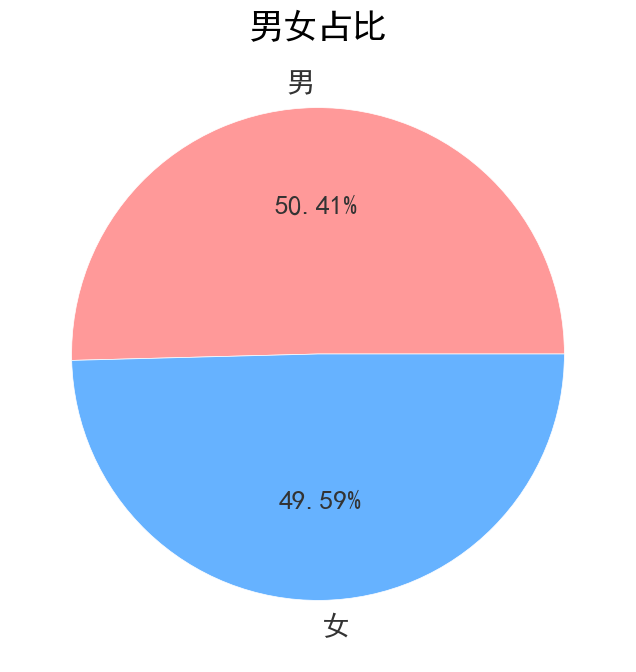

In [26]:
df_sex = data['sex'].value_counts() 
df = data[data['price']>0]

colors = ['#FF9999', '#66B2FF']  

plt.figure(figsize=(8,8))
plt.pie(
    df_sex.values,
    labels=df_sex.index,
    autopct='%.2f%%',
    colors=colors,
    wedgeprops={'linewidth':0.5,'edgecolor':'white'},
    textprops={'fontsize':20,'color':'#333333'}
) 
plt.savefig('../images/男女占比.png')
plt.title('男女占比', fontsize=25)
plt.show()

## 按年龄段

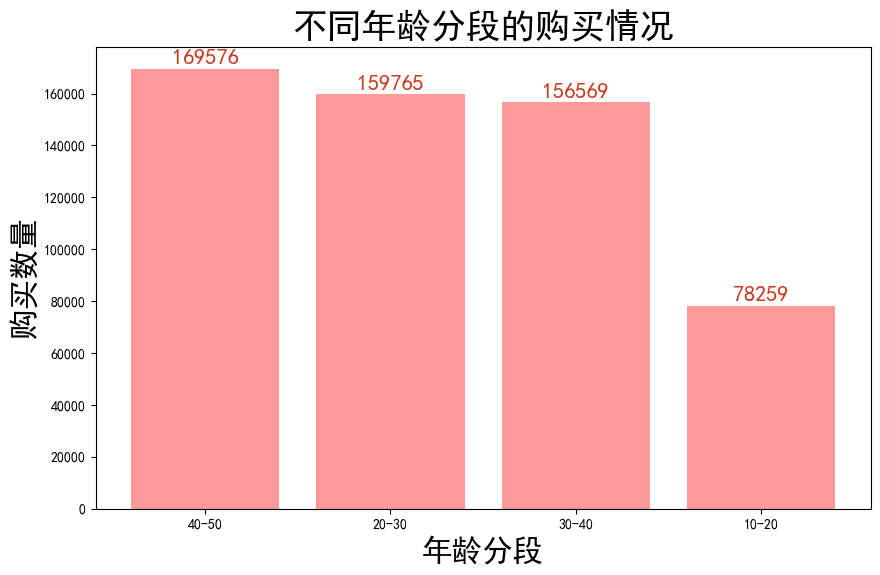

In [27]:
bins=[10,20,30,40,50] 
data['age_box'] = pd.cut(data['age'],bins,labels=['10-20','20-30','30-40','40-50']) 
age_box = data['age_box'].value_counts()
plt.figure(figsize=(10,6))

plt.bar(age_box.index, age_box.values, color='#FF9999')

plt.ylabel('购买数量', size=22)
plt.xlabel('年龄分段', size=22)
plt.title('不同年龄分段的购买情况', size=25)

for x, y in zip(age_box.index, age_box.values):
    plt.text(x, y+500, str(y),
             ha='center',
             va='bottom',
             size=16,
             color='#c83c23')

plt.savefig('../images/不同年龄分段的购买情况.png')
plt.show()

## 按品牌喜好

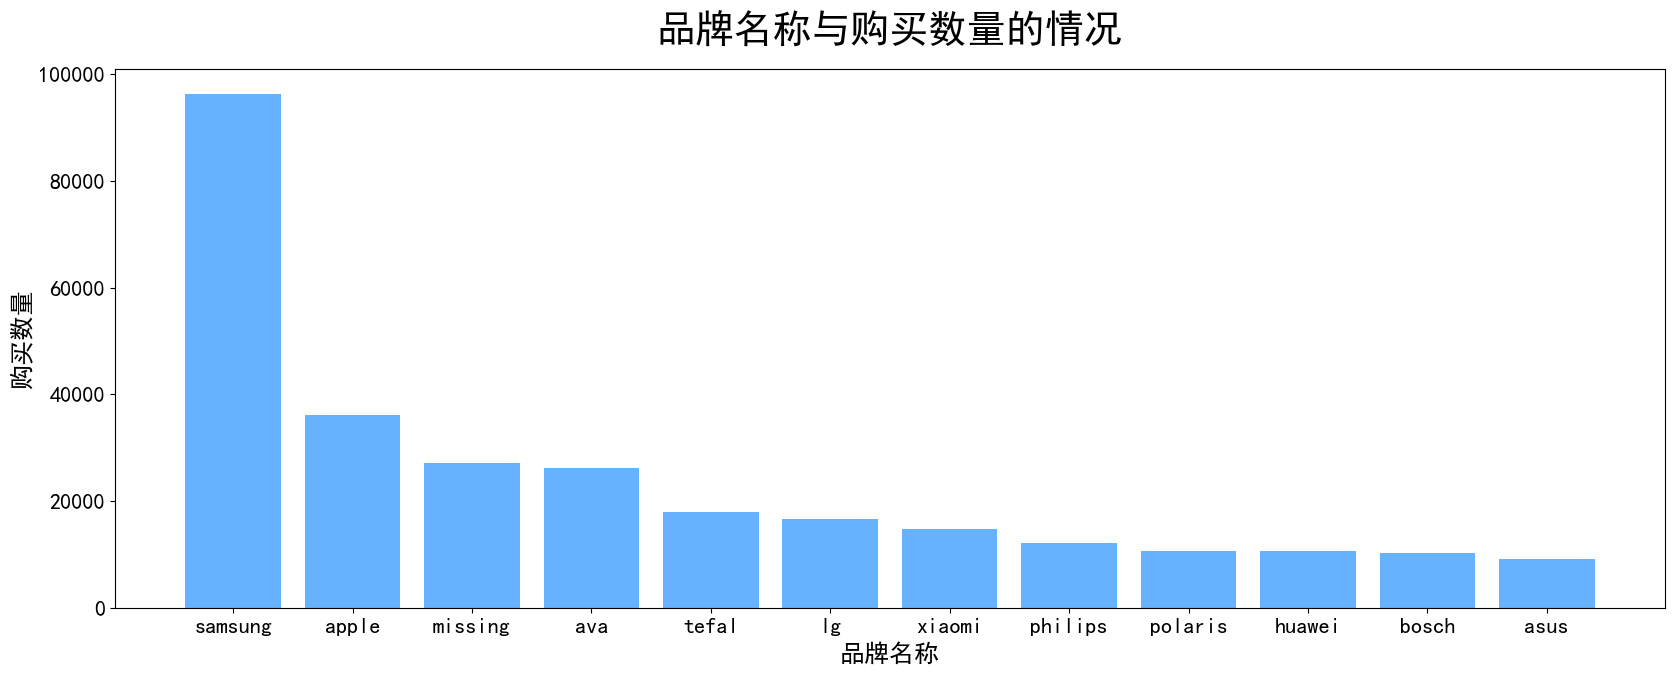

In [28]:
df_brand = df['brand'].value_counts().head(12)
plt.figure(figsize=(20,7))
plt.bar(df_brand.index, df_brand.values, color='#66B2FF')
plt.xticks(size=16)
plt.yticks(size=16)
plt.xlabel("品牌名称",size=18)
plt.ylabel("购买数量",size=18)
plt.title('品牌名称与购买数量的情况',size=28,pad=20)
plt.show()